In [1]:
import os

os.chdir("../..")

In [2]:
import pandas as pd
import numpy as np
from data.data import get_hiv_data, get_hiv_clf
#from src.e_crt import EcrtTester
#from src.sampling_functions import sample_hiv_data
#from src.utils import TanhBet, get_martingale_values

In [3]:
np.random.seed(0)
j_vec = [10, 61, 62]
batch_list = [2, 5, 10]#[5, 10, 20]
n_init = 20
#offline=True
#g_func = TanhBet()
#sampling_func = sample_hiv_data
#save_path = "./results/HIV"
X, Y, features_names = get_hiv_data()

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

models = {
    "Ridge (L2 linear)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),  # safe for sparse/binary-like data
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso (L1 linear)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("model", Lasso(alpha=0.001, max_iter=5000))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        random_state=42
    ),

    "Neural Network (MLP)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        Y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "R2": scores["test_r2"].mean(),
        "RMSE": -scores["test_rmse"].mean(),
        "MAE": -scores["test_mae"].mean()
    })

df_results = pd.DataFrame(results).sort_values("R2", ascending=False)
print(df_results.round(4))

/home/mind/areyerol/.local/miniconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/mind/areyerol/.local/miniconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/mind/areyerol/.local/miniconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/mind/areyerol/.local/miniconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vec

                    Model      R2    RMSE     MAE
1       Lasso (L1 linear)  0.8820  0.3013  0.2220
0       Ridge (L2 linear)  0.8796  0.3043  0.2241
3       Gradient Boosting  0.8699  0.3166  0.2337
4  Hist Gradient Boosting  0.8627  0.3254  0.2348
2           Random Forest  0.8412  0.3499  0.2541
5    Neural Network (MLP)  0.7433  0.4443  0.3309


In [5]:
os.chdir("src")

In [6]:
from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign


etas = prepare_exponential_parameters(0.01, 5, 10)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)



params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,

}

#batch_list = [1, 2, 5]
e_process = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )


In [7]:
martingales = e_process.martingales(X, y=Y)

In [8]:
martingales

{'exponential': {2: {10: array([1.        , 1.        , 1.        , ..., 1.65777322, 1.65777322,
          1.66026369], shape=(1555,)),
   61: array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
          1.06694955e+11, 1.06694955e+11, 1.06694955e+11], shape=(1555,)),
   62: array([  1.        ,   1.        ,   1.        , ..., 120.83291271,
          120.83291271, 120.83291271], shape=(1555,))},
  5: {10: array([1.        , 1.        , 1.        , ..., 1.15238679, 1.15238679,
          1.15238679], shape=(1555,)),
   61: array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
          8.91998372e+05, 8.91998372e+05, 8.91998372e+05], shape=(1555,)),
   62: array([ 1.        ,  1.        ,  1.        , ..., 26.63002582,
          26.63002582, 26.63002582], shape=(1555,))},
  10: {10: array([1.        , 1.        , 1.        , ..., 1.04605805, 1.04605805,
          1.04605805], shape=(1555,)),
   61: array([  1.       ,   1.       ,   1.       , ..., 790.7042397,
          

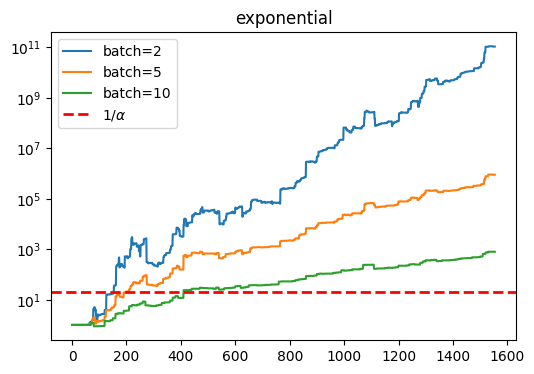

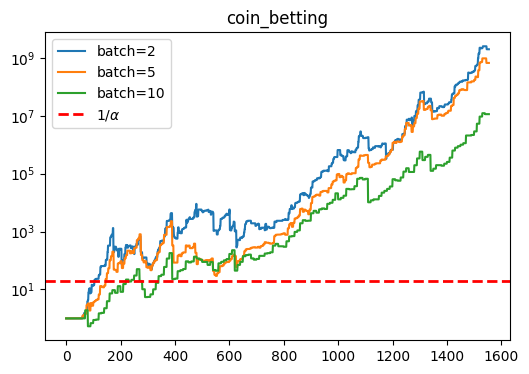

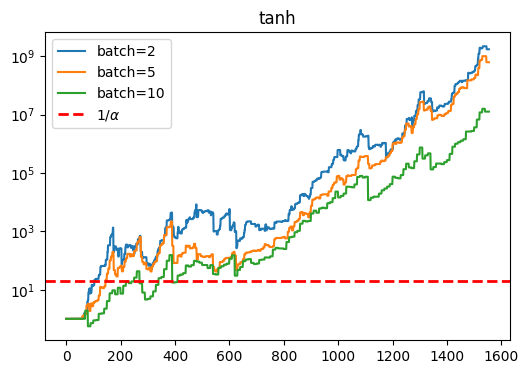

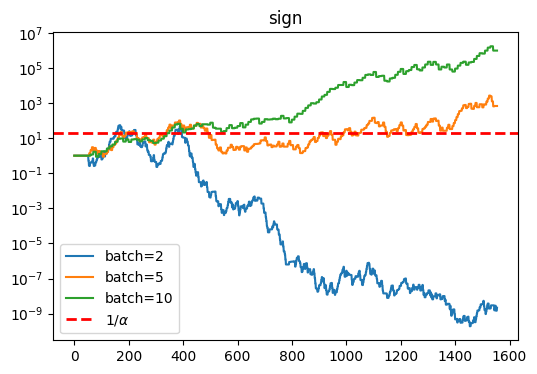

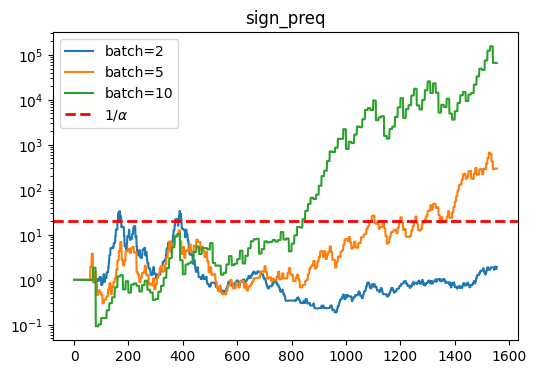

In [15]:
import matplotlib.pyplot as plt
alpha = 0.05
j = 61 #j_vec = [10, 61, 62]
for strategy_name in betting_strategies.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j],
            label=f"batch={b}"
        )
    plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()

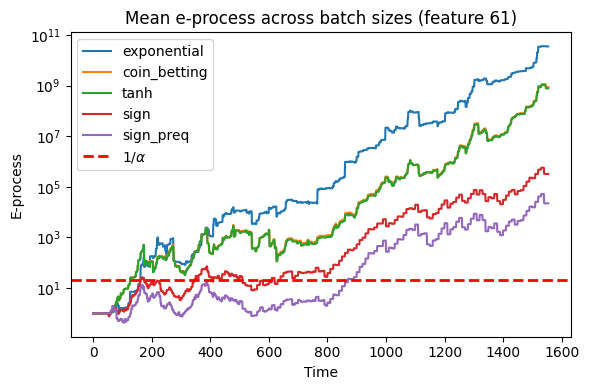

In [16]:
plt.figure(figsize=(6, 4))

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
batch_list = [2, 5, 10, 20]

e_process2 = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )


In [18]:
martingales2 = e_process2.martingales(X, y=Y)

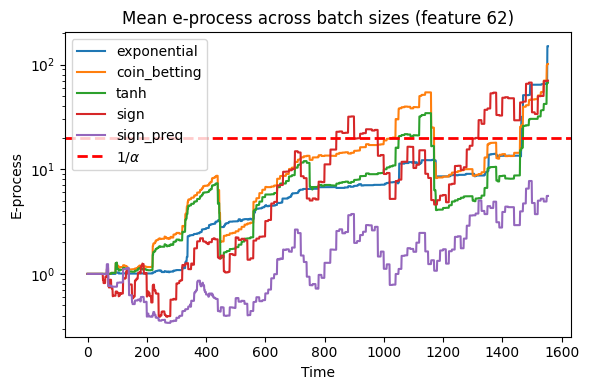

In [27]:
plt.figure(figsize=(6, 4))

j = 62
batch_list2 = [2, 5, 10, 20]
for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales2[strategy_name][b][j] for b in batch_list2],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()